## Table of Contents

1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
1. [Model Development](#Model-Development)
1. [Final Generalization Test](#Final-Generalization-Test)
1. [Submission File Generation](#Submission-File-Generation)

## Introduction

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, Kaggle asked us to build a predictive model that answers the question: **“What sorts of people were more likely to survive?”** using passenger data (e.g. name, age, gender, socio-economic class, etc).

In [157]:
from datetime import datetime
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import mlflow
import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message=".*Inferred schema contains integer column.*",
    module="mlflow\\.types\\.utils"
)

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import shap

## Data Understanding

Kaggle provided passenger data split into two files:
* "Training set" (<a href="./input/train.csv">train.csv</a>)
    * 891 rows, 12 features
* "Test set" (<a href="./input/test.csv">test.csv</a>)
    * 418 rows, 11 features (no `Survived` col)

As the "Test set" represents unseen data for use at submission time, I will refrain from loading the data at this time to mitigate data leakage risks.

To aid validating my models' generalizability to unseen data, I will set aside 20% of the Training Set data for final validation after optimizing model performance using cross-validation with the remaining Training Set data.

The `stratify=y` parameter was used to ensure equal distribution of the target variable across training and validation sets.

In [158]:
training_set_df = pd.read_csv('./input/train.csv')
target = 'Survived'

X = training_set_df.drop(columns=target)
y = training_set_df[target]

X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

* New Training set contains 712 samples
* New Validation set contains 179 samples

In [159]:
X_train.shape, X_val.shape

((712, 11), (179, 11))

### Data Dictionary

| Variable | Definition | Key, Example |
| -------- | ---------- | --- |
| **Survived** | Survival | 0 = No, 1 = Yes |
| **PassengerId** | Integer index of passenger | 0,1,2,3,... |
| **Name** | Name of passenger including title | Braund, Mr. Owen Harris |
| **Pclass** | Ticket class | 1 = 1st, 2 = 2nd, 3 = 3rd |
| **Sex** | Sex | female, male |
| **Age** | Age in years | 0.15, 2, 15 |
| **SibSp** | # of siblings / spouses aboard the Titanic | 0,1,2,3,.. |
| **Parch** | # of parents / children aboard the Titanic | 0,1,2,3,.. |
| **Ticket** | Ticket number, some with prefixes, **shared among groups** | SW/PP 751 |
| **Fare** | Passenger fare, **shared among groups**	 | 7.91, 14.4542, 512.3292 |
| **Cabin** | Cabin number(s) listed on ticket, prefixed with deck letter, **shared among groups**	 | A20, "B57 B59 B63 B66"	 |
| **Embarked** | Port of Embarkation | C = Cherbourg (France), Q = Queenstown (Ireland), S = Southampton (England) |

#### Variable Notes

**pclass:** A proxy for socio-economic status (SES)
* 1st = Upper
* 2nd = Middle
* 3rd = Lower

**age:** Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5

**sibsp:** The dataset defines family relations in this way...
* Sibling = brother, sister, stepbrother, stepsister
* Spouse = husband, wife (mistresses and fiancés were ignored)

**parch:** The dataset defines family relations in this way...
* Parent = mother, father
* Child = daughter, son, stepdaughter, stepson
* Some children travelled only with a nanny, therefore parch=0 for them.

### Descriptive Statistics

In [160]:
X_train.describe(include='number')

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,712.000000,712.000000,575.000000,712.000000,712.000000,712.000000
mean,444.405899,2.308989,29.807687,0.492978,0.390449,31.819826
std,257.465527,0.833563,14.485211,1.060720,0.838134,48.059104
min,1.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,439.500000,3.000000,28.500000,0.000000,0.000000,14.454200
75%,667.250000,3.000000,39.000000,1.000000,0.000000,31.000000
max,891.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Initial insights:
* **PassengerId:** column is most likely a sequential integer index from 1 to 891
* **Survived:** Mean survival rate for this data set is 38.4%
* **Pclass:** Top 25% of passengers were in 1st and 2nd Class, remainder in 3rd class
* **Age:** Youngest child was less than 6 months old, oldest is 80 years old.  Median age 28 yrs, 75th pecentile 38 yrs.  177 values missing
* **SibSp / Parch**:  At least 50% of passengers traveled alone, 75% passengers had at most 1 sibling or spouse.  Max family size is 8
* **Fare:** Fares ranged from 0.00 (potentially crew?) to 512.32.  Median fare 14.45, 75th percentile 31.00 - highest fares likely correlates with upper class

In [161]:
X_train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,712,712,712,160,710
unique,712,2,571,127,3
top,"Lam, Mr. Ali",male,1601,G6,S
freq,1,459,6,4,516


Initial insights:
* **Name:** Contains surname and title info, probable tokens for splitting
* **Sex:** Majority of passengers were male
* **Ticket:** Contains number; some contain prefixes with potentially useful info. 210 passengers shared the same ticket number, indicating traveling together (may be family and/or household staff)
* **Cabin:** Contains room number and deck letter prefix.  Some cabin strings contain multiple cabin numbers, may also signal family or household staff relationships.  687 values missing
* **Embarked:** Majority of passengers embarked from Southampton, England (644).  2 values missing

### Row Samples

In [162]:
X_train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S


### Data Types

In [163]:
X_train.dtypes

PassengerId      int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### Missing Values Summary

In [164]:
X_train.isnull().sum().loc[lambda x: x > 0]

Age         137
Cabin       552
Embarked      2
dtype: int64

### Sample Visual Inspection

Visual inspection shows variaion in **ticket prefixes**, **cabin numbers (e.g. multiple numbers)** and **name tokens (e.g. title, multiple names)**.

In [165]:
# Run multiple times to see different samples
X_train.sample(25)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
643,644,3,"Foo, Mr. Choong",male,NaN,0,0,1601,56.4958,NaN,S
474,475,3,"Strandberg, Miss. Ida Sofia",female,22.0,0,0,7553,9.8375,NaN,S
727,728,3,"Mannion, Miss. Margareth",female,NaN,0,0,36866,7.7375,NaN,Q
185,186,1,"Rood, Mr. Hugh Roscoe",male,NaN,0,0,113767,50.0000,A32,S
788,789,3,"Dean, Master. Bertram Vere",male,1.0,1,2,C.A. 2315,20.5750,NaN,S
584,585,3,"Paulner, Mr. Uscher",male,NaN,0,0,3411,8.7125,NaN,C
284,285,1,"Smith, Mr. Richard William",male,NaN,0,0,113056,26.0000,A19,S
193,194,2,"Navratil, Master. Michel M",male,3.0,1,1,230080,26.0000,F2,S
86,87,3,"Ford, Mr. William Neal",male,16.0,1,3,W./C. 6608,34.3750,NaN,S
323,324,2,"Caldwell, Mrs. Albert Francis (Sylvia Mae Harb...",female,22.0,1,1,248738,29.0000,NaN,S


## Feature Engineering

In [166]:
def engineer_features(df):

    # Create Sex Encoded feature
    df['Sex_Encoded'] = df['Sex'].map({'male': 0, 'female': 1})

    # One-hot encode Pclass
    pclass_dummies = pd.get_dummies(df['Pclass'], prefix='Pclass', drop_first=True)
    df = pd.concat([df, pclass_dummies], axis=1)

    # Create Deck feature from CabinCabin
    df['Deck'] = df['Cabin'].str[0]

    # Fill missing Deck values with 'U' for Unknown
    df['Deck'] = df['Deck'].fillna('U')

    # Create Title feature from Name
    def extract_title(name):
        title = name.split(',')[1].split('.')[0].strip()
        return title
    df['Title'] = df['Name'].apply(extract_title)

    # Create Surname feature from Name
    def extract_surname(name):
        surname = name.split(',')[0].strip()
        return surname
    df['Surname'] = df['Name'].apply(extract_surname)

    # Create Ticket Prefix and Number features from Ticket
    def extract_ticket_info(ticket):
        if pd.isnull(ticket):
            return None, None
        parts = ticket.split()
        prefix = parts[0] if len(parts) > 1 else ''
        number = parts[-1] if len(parts) > 1 else parts[0]
        return prefix, number
    df[['Ticket_Prefix', 'Ticket_Number']] = df['Ticket'].apply(lambda x: pd.Series(extract_ticket_info(x)))

    # Print non-numeric Ticket Numbers in training data with counts
    non_numeric_ticket_numbers = df[~df['Ticket_Number'].str.isnumeric()]['Ticket_Number'].value_counts()
    print("Non-numeric Ticket Numbers in training data:")
    print(non_numeric_ticket_numbers)

    # Set 4 'LINE' Ticket Numbers to -1
    df.loc[df['Ticket_Number'].isin(['LINE']), 'Ticket_Number'] = -1

    # Create Ticket Frequency feature from Ticket Number on training data only
    #ticket_freq_train = X_train['Ticket_Number'].value_counts().to_dict()
    #df['Ticket_Frequency'] = df['Ticket_Number'].map(ticket_freq_train)

    # Calculate Fare per Person
    #df['Fare_Per_Person'] = df['Fare'] / df['Ticket_Frequency']
    #df['Fare_Per_Person_Scaled'] = (df['Fare_Per_Person'] - df['Fare_Per_Person'].mean()) / df['Fare_Per_Person'].std()

    # def bin_ticket_frequency(freq):
    #     if freq < 4:
    #         return freq
    #     else:
    #         return 4
    # df['Ticket_Frequency'] = df['Ticket_Frequency'].apply(bin_ticket_frequency)

    # Create Family Size feature
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1
    def bin_family_size(size):
        if size < 4:
            return size
        else:
            return 4
    df['Family_Size'] = df['Family_Size'].apply(bin_family_size)

    # Bin Parch and SibSp
    def bin_parch(parch):
        if parch < 3:
            return parch
        else:
            return 3
    df['Parch'] = df['Parch'].apply(bin_parch)

    def bin_sibsp(sibsp):
        if sibsp < 2:
            return sibsp
        else:
            return 2
    df['SibSp'] = df['SibSp'].apply(bin_sibsp)

    # Create Is_Alone feature
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # Create Cabin_Count feature from Cabin
    df['Cabin_Count'] = df['Cabin'].apply(lambda x: len(x.split()) if pd.notnull(x) else 0)
    def bin_cabin_count(cabin_count):
        if cabin_count < 2:
            return cabin_count
        else:
            return 2
    df['Cabin_Count'] = df['Cabin_Count'].apply(bin_cabin_count)

    # Create Cabin Number feature
    df['Cabin_Number'] = df['Cabin'].str.extract(r'(\d+)')

    # Create Port or Starboard feature based on Cabin Number
    def cabin_side(cabin_number):
        if pd.isnull(cabin_number):
            return 'Unknown'
        if cabin_number.isdigit():
            return 'Starboard' if int(cabin_number) % 2 == 0 else 'Port'
        return 'Unknown'
    df['Cabin_Side'] = df['Cabin_Number'].apply(cabin_side)

    # Create Cabin_Missing feature
    df['Cabin_Missing'] = df['Cabin'].isnull().astype(int)

    # Fill missing Cabin_Number values with 0
    df['Cabin_Number'] = df['Cabin_Number'].fillna(0).astype(int)

    # Drop original Cabin column
    df.drop(columns=['Cabin'], inplace=True)

    # Create Scaled Fare feature
    df['Fare_Scaled'] = (df['Fare'] - df['Fare'].mean()) / df['Fare'].std()

    # Create Age_Missing feature
    df['Age_Missing'] = df['Age'].isnull().astype(int)

    # Imput missing Age values using median of Pclass/Title gr
    def impute_age(df):

        # First attempt to impute by Pclass X Title
        pclass_title_age_median_map = df.groupby(['Pclass', 'Title'])['Age'].median()
        def impute_age_by_pclass_title(row):
            if pd.notna(row['Age']):
                return row['Age']
            return pclass_title_age_median_map.loc[row['Pclass'], row['Title']]
        df['Age'] = df.apply(impute_age_by_pclass_title, axis=1)

        # In the scenario where all ages for a given title are missing, impute with median age for Sex
        sex_age_median_map = df.groupby(['Sex'])['Age'].median()
        def impute_age_by_sex(row):
            if pd.notna(row['Age']):
                return row['Age']
            return sex_age_median_map.loc[row['Sex']]
        df['Age'] = df.apply(impute_age_by_sex, axis=1)
    impute_age(df)

    df['Is_Child'] = (df['Age'] < 10).astype(int)
    df['Age_Scaled'] = (df['Age'] - df['Age'].mean()) / df['Age'].std()

    age_bins = [0, 10, 25, 30, np.inf]
    age_labels = ['(0–10]', '(10–25]', '(25–30]', '(30+)']
    df['Age_Bin'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)
    age_dummies = pd.get_dummies(df['Age_Bin'], prefix='AgeBin', drop_first=True)
    df.drop(columns=['Age_Bin'], inplace=True)
    df = pd.concat([df, age_dummies], axis=1)
    
    # One-hot encode Pclass concatenated with Cabin_Count
    df['Pclass_Cabin_Count'] = df['Pclass'].astype(str) + '_' + df['Cabin_Count'].astype(str)
    pclass_cabin_count_dummies = pd.get_dummies(df['Pclass_Cabin_Count'], prefix='Pclass_Cabin_Count', drop_first=True)
    df.drop(columns=['Pclass_Cabin_Count'], inplace=True)
    df = pd.concat([df, pclass_cabin_count_dummies], axis=1)

    # One-hot encode Pclass concatenated with Family_Size
    df['Pclass_Family_Size'] = df['Pclass'].astype(str) + '_' + df['Family_Size'].astype(str)
    pclass_family_size_dummies = pd.get_dummies(df['Pclass_Family_Size'], prefix='Pclass_Family_Size', drop_first=True)
    df.drop(columns=['Pclass_Family_Size'], inplace=True)
    df = pd.concat([df, pclass_family_size_dummies], axis=1)

    return df


In [167]:
X_train = engineer_features(X_train)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    3
Name: count, dtype: int64


In [168]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 692 to 507
Data columns (total 49 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PassengerId             712 non-null    int64  
 1   Pclass                  712 non-null    int64  
 2   Name                    712 non-null    object 
 3   Sex                     712 non-null    object 
 4   Age                     712 non-null    float64
 5   SibSp                   712 non-null    int64  
 6   Parch                   712 non-null    int64  
 7   Ticket                  712 non-null    object 
 8   Fare                    712 non-null    float64
 9   Embarked                710 non-null    object 
 10  Sex_Encoded             712 non-null    int64  
 11  Pclass_2                712 non-null    bool   
 12  Pclass_3                712 non-null    bool   
 13  Deck                    712 non-null    object 
 14  Title                   712 non-null    objec

In [169]:
# Create categorical and numerical feature lists
target = 'Survived'
base_categorical_features = [
   'Deck', 
   'Title', 
   'Embarked', 
   'Surname', 
   'Ticket_Prefix', 
   'Cabin_Number', 
   'Ticket_Number', 
   'Cabin_Side'
]
base_numerical_features = [
   'Sex_Encoded', 
   'Is_Alone', 
   'Fare_Scaled',
   'AgeBin_(10–25]', 'AgeBin_(25–30]', 'AgeBin_(30+)',
   'Pclass_Cabin_Count_1_1',
   'Pclass_Cabin_Count_1_2',
   'Pclass_Cabin_Count_2_0',
   'Pclass_Cabin_Count_2_1',
   'Pclass_Cabin_Count_3_0',
   'Pclass_Cabin_Count_3_1',
   'Pclass_Cabin_Count_3_2',
   'Pclass_Family_Size_1_2',
   'Pclass_Family_Size_1_3',
   'Pclass_Family_Size_1_4',
   'Pclass_Family_Size_2_1',
   'Pclass_Family_Size_2_2',
   'Pclass_Family_Size_2_3',
   'Pclass_Family_Size_2_4',
   'Pclass_Family_Size_3_1',
   'Pclass_Family_Size_3_2',
   'Pclass_Family_Size_3_3',
   'Pclass_Family_Size_3_4',
   'Pclass_2',
   'Pclass_3',
]

In [170]:
def remove_duplicates(X_df, features, y_df=None):
    """ Remove duplicate rows based on specified features. """

    # Combine features and target into a single DataFrame
    if y_df is None:
        y_df = pd.Series([None] * len(X_df), name='Target')
    df = pd.concat([X_df[features], y_df], axis=1)

    # Check for duplicates
    train_duplicates = df[features].duplicated().sum()
    print(f"Number of duplicate rows in train set: {train_duplicates}")

    # Drop duplicates to reduce multicollinearity
    X_df = X_df.drop_duplicates(subset=features)

    # Drop corresponding target values
    y_df = y_df[X_df.index]

    # Check for duplicates
    check_train_duplicates = X_df[features].duplicated().sum()
    print(f"Number of duplicate rows in train set after dropping: {check_train_duplicates}")

In [171]:
remove_duplicates(X_train, base_categorical_features + base_numerical_features, y_train)

Number of duplicate rows in train set: 17
Number of duplicate rows in train set after dropping: 0


## Exploratory Data Analysis

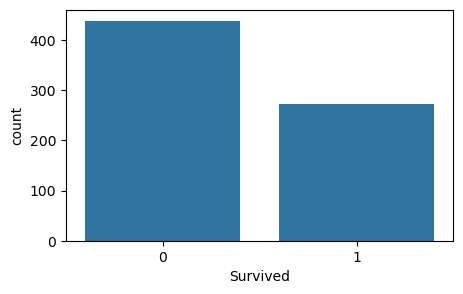

Global Survival Rate: 0.3834
Baseline Accuracy (if predicting majority class): 0.6166


In [172]:
y_df = pd.DataFrame(y_train).reset_index(drop=True)

plt.figure(figsize=(5, 3))
sns.countplot(x='Survived', data=y_df)
plt.show()

global_survival_rate = y_df['Survived'].mean()
print(f"Global Survival Rate: {global_survival_rate:.4f}")
print(f"Baseline Accuracy (if predicting majority class): {max(global_survival_rate, 1 - global_survival_rate):.4f}") 

In [173]:
def plot_corr_heatmap(feature_df, target_series, figsize=(10, 8)):
    """
    Plots a correlation heatmap for the given features and target.

    Args:
        df (pd.DataFrame): DataFrame containing the data.
        features (list): List of feature column names.
        target (str): Name of the target column.
        figsize (tuple): Figure size for the heatmap.
    """
    concat_df = pd.concat([feature_df, target_series], axis=1)
    correlation_matrix = concat_df.corr()
    plt.figure(figsize=figsize)
    sns.heatmap(
        correlation_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        square=True,
        cbar_kws={"shrink": .8}
    )
    plt.title("Correlation Heatmap")
    plt.show()
    return correlation_matrix


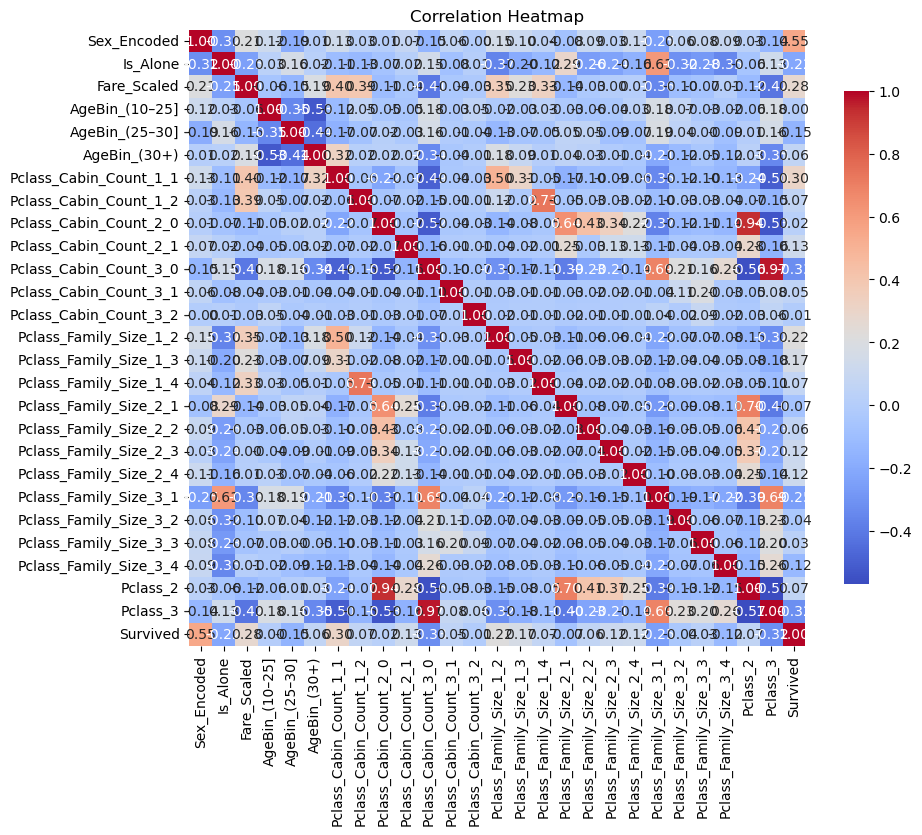

Correlation with target:
Survived                  1.000000
Sex_Encoded               0.549171
Pclass_Cabin_Count_1_1    0.304410
Fare_Scaled               0.275499
Pclass_Family_Size_1_2    0.220277
Pclass_Family_Size_1_3    0.167422
Pclass_Cabin_Count_2_1    0.125686
Pclass_Family_Size_2_4    0.121152
Pclass_Family_Size_2_3    0.116356
Pclass_Family_Size_1_4    0.067805
Pclass_2                  0.067194
Pclass_Cabin_Count_1_2    0.065059
Pclass_Family_Size_2_2    0.064663
AgeBin_(30+)              0.061919
Pclass_Cabin_Count_3_1    0.053702
Pclass_Family_Size_3_3    0.026597
Pclass_Cabin_Count_2_0    0.023856
AgeBin_(10–25]            0.000613
Pclass_Cabin_Count_3_2   -0.006702
Pclass_Family_Size_3_2   -0.042288
Pclass_Family_Size_2_1   -0.070430
Pclass_Family_Size_3_4   -0.124593
AgeBin_(25–30]           -0.154683
Is_Alone                 -0.215570
Pclass_Family_Size_3_1   -0.252218
Pclass_3                 -0.318827
Pclass_Cabin_Count_3_0   -0.327106
Name: Survived, dtype: float64

In [174]:
correlation_matrix = plot_corr_heatmap(X_train[base_numerical_features], y_train)
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
print("Correlation with target:")
print(correlation_with_target)

In [175]:
vif_minimized_feature_list = [
    'Sex_Encoded',
    #'Family_Size',
    #'Is_Alone',
    'Age_Missing',
    #'Fare_Scaled',
    'AgeBin_(10–25]',
    'AgeBin_(25–30]',
    'AgeBin_(30+)',
    'Pclass_Cabin_Count_1_1',
    'Pclass_Cabin_Count_1_2',
    'Pclass_Cabin_Count_2_0',
    #'Pclass_Cabin_Count_2_1',
    'Pclass_Cabin_Count_3_0',
    'Pclass_Cabin_Count_3_1',
    #'Pclass_Cabin_Count_3_2',
    'Pclass_Family_Size_1_2',
    'Pclass_Family_Size_1_3',
    'Pclass_Family_Size_1_4',
    'Pclass_Family_Size_2_1',
    'Pclass_Family_Size_2_2',
    'Pclass_Family_Size_2_3',
    'Pclass_Family_Size_2_4',
    'Pclass_Family_Size_3_1',
    'Pclass_Family_Size_3_2',
    'Pclass_Family_Size_3_3',
    #'Pclass_Family_Size_3_4',
]

# Check Variance Inflation Factor (VIF) of each feature
X_vif = add_constant(X_train[vif_minimized_feature_list])
X_vif = X_vif.astype(float)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print(vif_data)

                   Feature        VIF
0                    const  40.298749
1              Sex_Encoded   1.191475
2              Age_Missing   1.270266
3           AgeBin_(10–25]   4.654164
4           AgeBin_(25–30]   4.509827
5             AgeBin_(30+)   5.270650
6   Pclass_Cabin_Count_1_1   3.788687
7   Pclass_Cabin_Count_1_2   2.584564
8   Pclass_Cabin_Count_2_0   8.519123
9   Pclass_Cabin_Count_3_0   8.667704
10  Pclass_Cabin_Count_3_1   1.419532
11  Pclass_Family_Size_1_2   1.612131
12  Pclass_Family_Size_1_3   1.216097
13  Pclass_Family_Size_1_4   2.252811
14  Pclass_Family_Size_2_1   7.371866
15  Pclass_Family_Size_2_2   4.097989
16  Pclass_Family_Size_2_3   3.296333
17  Pclass_Family_Size_2_4   2.061398
18  Pclass_Family_Size_3_1   4.579407
19  Pclass_Family_Size_3_2   1.820425
20  Pclass_Family_Size_3_3   1.592800


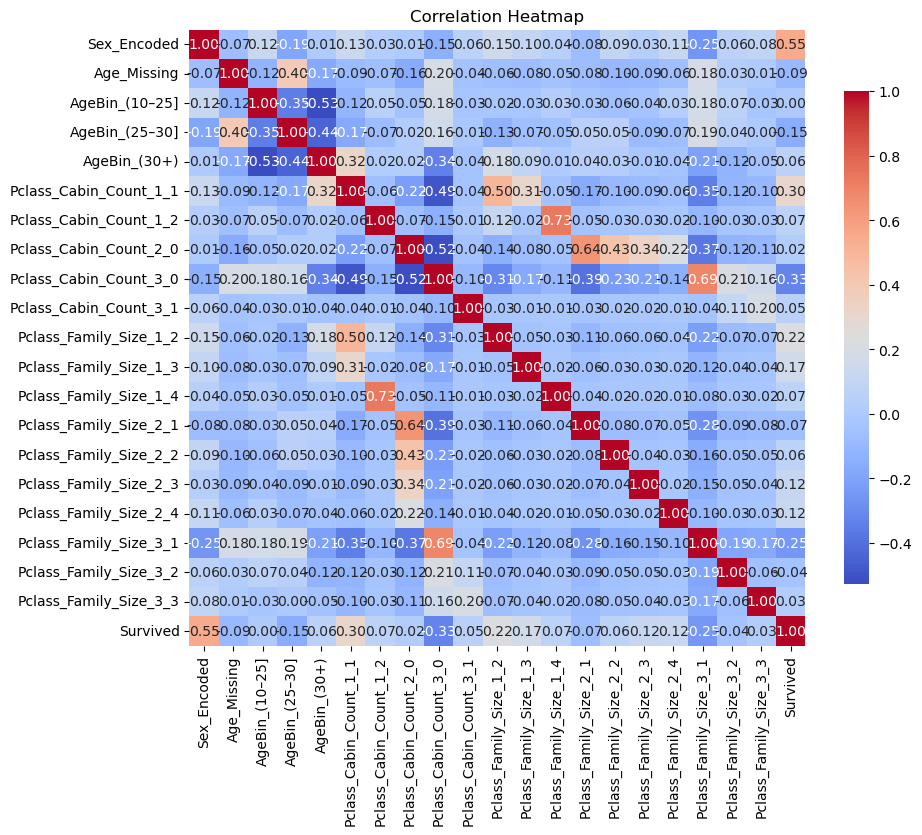

In [176]:
correlation_matrix = plot_corr_heatmap(X_train[vif_minimized_feature_list], y_train)

In [177]:
correlation_with_target = correlation_matrix[target].sort_values(ascending=False)
print("Correlation with target:")
print(correlation_with_target)

Correlation with target:
Survived                  1.000000
Sex_Encoded               0.549171
Pclass_Cabin_Count_1_1    0.304410
Pclass_Family_Size_1_2    0.220277
Pclass_Family_Size_1_3    0.167422
Pclass_Family_Size_2_4    0.121152
Pclass_Family_Size_2_3    0.116356
Pclass_Family_Size_1_4    0.067805
Pclass_Cabin_Count_1_2    0.065059
Pclass_Family_Size_2_2    0.064663
AgeBin_(30+)              0.061919
Pclass_Cabin_Count_3_1    0.053702
Pclass_Family_Size_3_3    0.026597
Pclass_Cabin_Count_2_0    0.023856
AgeBin_(10–25]            0.000613
Pclass_Family_Size_3_2   -0.042288
Pclass_Family_Size_2_1   -0.070430
Age_Missing              -0.091813
AgeBin_(25–30]           -0.154683
Pclass_Family_Size_3_1   -0.252218
Pclass_Cabin_Count_3_0   -0.327106
Name: Survived, dtype: float64


### Linear Relationship Assessment

#### Sex_Encoded

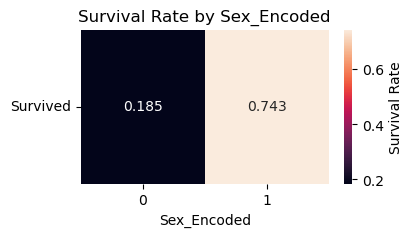

In [178]:
# Create survival rate heatmap for Sex_Encoded
survival_heatmap_data = pd.concat([X_train, y_train], axis=1).groupby('Sex_Encoded')['Survived'].mean().to_frame().T

plt.figure(figsize=(4, 2))
sns.heatmap(survival_heatmap_data, annot=True, fmt='.3f', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate by Sex_Encoded')
plt.yticks(rotation=0)
plt.show()

#### Fare_Scaled

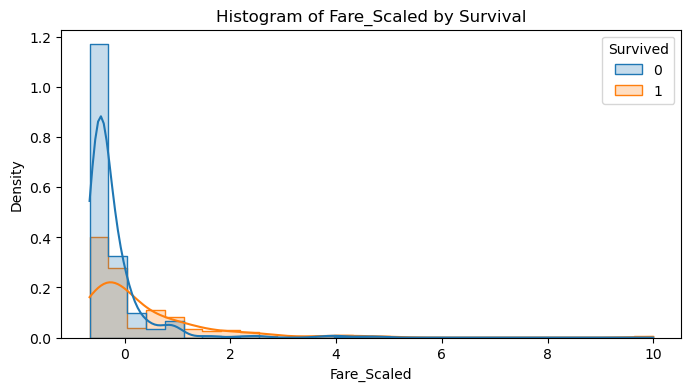

In [179]:
plt.figure(figsize=(8, 4))
sns.histplot(data=pd.concat([X_train, y_train], axis=1), x='Fare_Scaled', hue='Survived', bins=30, kde=True, element='step', stat='density')
plt.title('Histogram of Fare_Scaled by Survival')
plt.xlabel('Fare_Scaled')
plt.ylabel('Density')
plt.show()

#### Pclass vs Family_Size

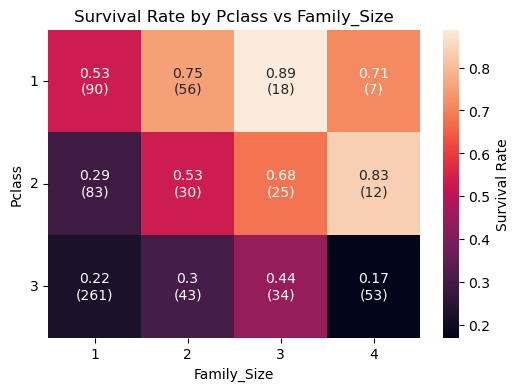

In [180]:
# Create survival rate heatmap for Pclass vs Family_Size
pclass_family_heatmap_data = pd.concat([X_train, y_train], axis=1).groupby(['Pclass', 'Family_Size'])['Survived'].mean().unstack()
plt.figure(figsize=(6, 4))

# Annotate with both survival rate and count
counts = pd.concat([X_train, y_train], axis=1).groupby(['Pclass', 'Family_Size'])['Survived'].count().unstack()
annot = pclass_family_heatmap_data.round(2).astype(str) + "\n(" + counts.astype(int).astype(str) + ")"
sns.heatmap(
    pclass_family_heatmap_data,
    annot=annot,
    fmt='',
    cbar_kws={'label': 'Survival Rate'}
)
plt.title('Survival Rate by Pclass vs Family_Size')
plt.yticks(rotation=0)
plt.show()

#### Age_Missing

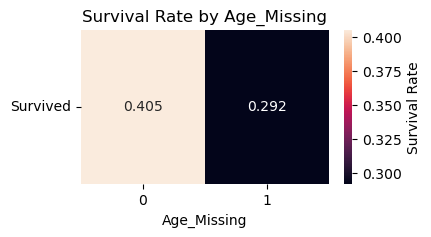

In [181]:
# Create survival rate heatmap for Age_Missing
survival_heatmap_data = pd.concat([X_train, y_train], axis=1).groupby('Age_Missing')['Survived'].mean().to_frame().T
plt.figure(figsize=(4, 2))
sns.heatmap(survival_heatmap_data, annot=True, fmt='.3f', cbar_kws={'label': 'Survival Rate'})
plt.title('Survival Rate by Age_Missing')
plt.yticks(rotation=0)
plt.show()

## Model Development

Notes:
* Numerical features with linear/sigmoidal relationship with Survival seleted for LogisticRegression model.
    * Planning to layer in additional features with ensemble of tree-based XGBoostClassifier.
* Variance Inflation Factor (VIF) reduced to < 5 for Logistic Regression model features.
* `Pclass_x_Family_Size` exhibited non-linear relationship with Survival best modeled with tree-based algorithms.

In [182]:
mlflow.set_tracking_uri('http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/')
mlflow.set_experiment('titanic_ml_from_disaster__abridged')

<Experiment: artifact_location='s3://thoughtswork-co/mlflow/3', creation_time=1749424560671, experiment_id='3', last_update_time=1749424560671, lifecycle_stage='active', name='titanic_ml_from_disaster__abridged', tags={}>

In [183]:
# Train and evaluate a Logistic Regression model
numerical_features_to_test = vif_minimized_feature_list

X_numerical = X_train[numerical_features_to_test]

clf = LogisticRegression(random_state=42, class_weight='balanced')

scoring = {
    'acc':    'accuracy',
    'prec':   'precision_macro',
    'rec':    'recall_macro',
    'f1':     'f1_macro',
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

with mlflow.start_run():
    mlflow.set_tag("scope", "cv")

    print(f"\nEvaluating model with {len(X_numerical.columns)} features:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    cv_results = cross_validate(clf, X_numerical, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    for metric_name, values in cv_results.items():
        if metric_name.startswith('test_'):
            mean_val = values.mean()
            std_val  = values.std()
            mlflow.log_metric(f"{metric_name}", mean_val)
            mlflow.log_metric(f"{metric_name}_std", std_val)

    summary = {
        metric: f"{vals.mean():.3f} ± {vals.std():.3f}"
        for metric, vals in cv_results.items()
        if metric.startswith('test_')
    }
    print("\nCross-validation results:")
    print(summary)


Evaluating model with 20 features:
* Sex_Encoded
* Age_Missing
* AgeBin_(10–25]
* AgeBin_(25–30]
* AgeBin_(30+)
* Pclass_Cabin_Count_1_1
* Pclass_Cabin_Count_1_2
* Pclass_Cabin_Count_2_0
* Pclass_Cabin_Count_3_0
* Pclass_Cabin_Count_3_1
* Pclass_Family_Size_1_2
* Pclass_Family_Size_1_3
* Pclass_Family_Size_1_4
* Pclass_Family_Size_2_1
* Pclass_Family_Size_2_2
* Pclass_Family_Size_2_3
* Pclass_Family_Size_2_4
* Pclass_Family_Size_3_1
* Pclass_Family_Size_3_2
* Pclass_Family_Size_3_3

Cross-validation results:
{'test_acc': '0.789 ± 0.040', 'test_prec': '0.781 ± 0.039', 'test_rec': '0.793 ± 0.038', 'test_f1': '0.783 ± 0.040'}
🏃 View run grandiose-zebra-305 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/7011524c7d754d739d8b43d4925fd40d
🧪 View experiment at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3


## Generalization Test

In [184]:
# Prepare validation set for prediction
X_val = engineer_features(X_val)
remove_duplicates(X_val, base_categorical_features + base_numerical_features, y_val)

Non-numeric Ticket Numbers in training data:
Ticket_Number
LINE    1
Name: count, dtype: int64
Number of duplicate rows in train set: 1
Number of duplicate rows in train set after dropping: 0



Evaluating model with 20 features:
* Sex_Encoded
* Age_Missing
* AgeBin_(10–25]
* AgeBin_(25–30]
* AgeBin_(30+)
* Pclass_Cabin_Count_1_1
* Pclass_Cabin_Count_1_2
* Pclass_Cabin_Count_2_0
* Pclass_Cabin_Count_3_0
* Pclass_Cabin_Count_3_1
* Pclass_Family_Size_1_2
* Pclass_Family_Size_1_3
* Pclass_Family_Size_1_4
* Pclass_Family_Size_2_1
* Pclass_Family_Size_2_2
* Pclass_Family_Size_2_3
* Pclass_Family_Size_2_4
* Pclass_Family_Size_3_1
* Pclass_Family_Size_3_2
* Pclass_Family_Size_3_3

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

Final Generalization Test Scores:
Test accuracy : 0.7374301675977654
Test precision: 0.731265664160401
Test recall   : 0.7431488801054018
Test F1-score : 0.7317710824167065
🏃 View run sassy-whale-869 at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3/runs/fe58e0b8e56b40b486fe00f7b25da466
🧪 View experiment at: http://ec2-18-220-145-217.us-east-2.compute.amazonaws.com:5000/#/experiments/3

Model Coefficients:
 

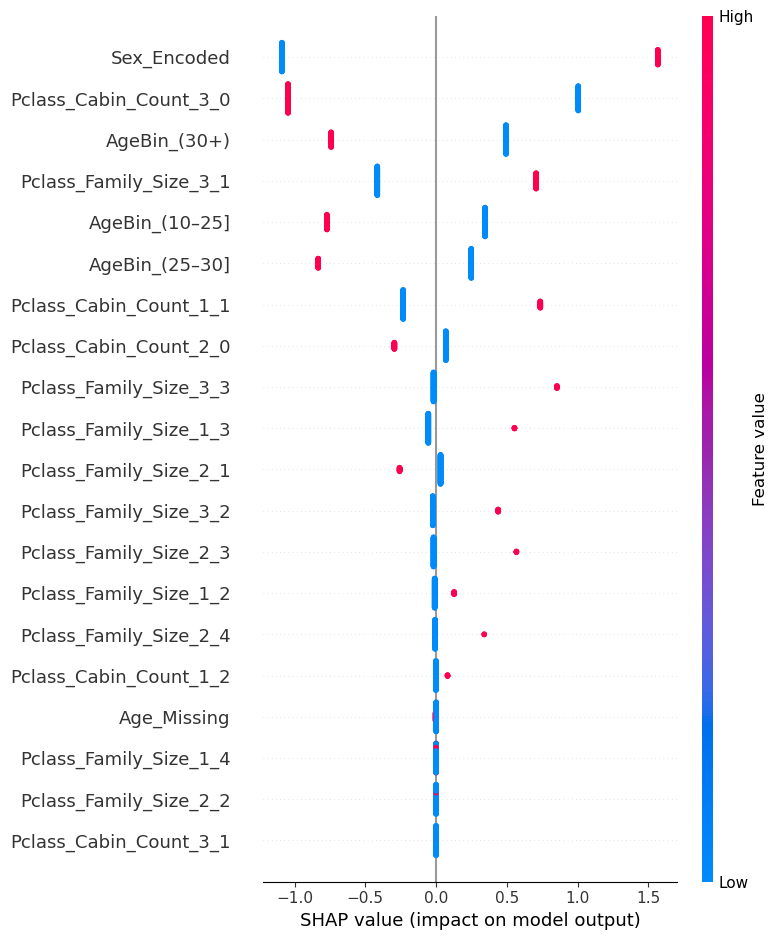

In [185]:
with mlflow.start_run():
    mlflow.set_tag("scope", "full_train")

    print(f"\nEvaluating model with {len(X_numerical.columns)} features:")
    for i, feat in enumerate(X_numerical.columns):
        print(f"* {feat}")
        mlflow.log_param(f"feature_{i}", feat)

    param_grid = {
        'penalty': ['l1', 'l2'],
        'C': [1, 0.5, 0.1, 0.05, 0.01],
        'solver': ['liblinear'], 
    }

    search = GridSearchCV(clf, param_grid, cv=cv, scoring='f1') 
    search.fit(X_train[numerical_features_to_test], y_train)
    
    best_params = search.best_params_
    print(f"\nBest parameters: {best_params}")
    mlflow.log_params(best_params)

    clf = search.best_estimator_
    
    # y_probs = clf.predict_proba(X_val[numerical_features_to_test])[:, 1]
    # threshold = 0.4
    # y_pred = (y_probs >= threshold).astype(int)

    y_pred = clf.predict(X_val[numerical_features_to_test])

    acc  = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='macro')
    rec  = recall_score(y_val, y_pred, average='macro')
    f1   = f1_score(y_val, y_pred, average='macro')

    print("\nFinal Generalization Test Scores:")
    print("Test accuracy :", acc)
    print("Test precision:", prec)
    print("Test recall   :", rec)
    print("Test F1-score :", f1)

    mlflow.log_metric("test_acc",  acc)
    mlflow.log_metric("test_prec", prec)
    mlflow.log_metric("test_rec",  rec)
    mlflow.log_metric("test_f1",   f1)

    # Infer the model signature
    # signature = mlflow.models.infer_signature(X_train[numerical_features_to_test], clf.predict(X_train[numerical_features_to_test]))

    # Log the model
    # model_info = mlflow.sklearn.log_model(
    #     sk_model=clf,
    #     artifact_path="titanic-ml-from-disaster_model_abridged",
    #     signature=signature,
    #     input_example=X_train[numerical_features_to_test],
    #     registered_model_name="titanic-ml-from-disaster__full_train")

# Output clf coefficients
if hasattr(clf, 'coef_'):
    coef_df = pd.DataFrame(clf.coef_.T, index=X_numerical.columns, columns=['Coefficient'])
    print("\nModel Coefficients:")
    print(coef_df.sort_values(by='Coefficient', ascending=False))

# Output SHAP Summary Plot
# Ensure all data is proper numeric type
X_train_shap = X_train[numerical_features_to_test].astype(np.float64)
X_val_shap = X_val[numerical_features_to_test].astype(np.float64)
explainer   = shap.LinearExplainer(clf, X_train_shap)
shap_values = explainer.shap_values(X_val_shap)
shap.summary_plot(
    shap_values, X_val_shap, plot_type='dot', show=True,
    max_display=100
)

## Submission File Generation

In [186]:
submission_test_X = pd.read_csv('./input/test.csv')

In [187]:
submission_test_X.isnull().sum().loc[lambda x: x > 0]

Age       86
Fare       1
Cabin    327
dtype: int64

In [188]:
submission_test_X[submission_test_X['Fare'].isnull()]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
152,1044,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S


In [189]:
submission_test_X['Fare'] = submission_test_X['Fare'].fillna(submission_test_X.groupby(['Pclass', 'Embarked'])['Fare'].transform('median'))

In [190]:
submission_test_X.isnull().sum().loc[lambda x: x > 0]

Age       86
Cabin    327
dtype: int64

In [191]:
submission_test_X = engineer_features(submission_test_X)
remove_duplicates(submission_test_X, base_categorical_features + base_numerical_features)

Non-numeric Ticket Numbers in training data:
Series([], Name: count, dtype: int64)
Number of duplicate rows in train set: 2
Number of duplicate rows in train set after dropping: 0


In [192]:
submission = pd.DataFrame({
    'PassengerId': submission_test_X['PassengerId'],
    'Survived': clf.predict(submission_test_X[numerical_features_to_test])
})
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
filename = f'./submission-{timestamp}.csv'
submission.to_csv(filename, index=False)

-----------

In [193]:
import json
import re

def slugify(text):
    text = text.strip()
    text = re.sub(r'[^\w\s\-]', '', text)  # allow (), - and alphanumerics
    return re.sub(r'[\s]+', '-', text)

def extract_headings(ipynb_path):
    with open(ipynb_path, 'r', encoding='utf-8') as f:
        nb = json.load(f)

    toc_lines = [] # ["## Table of Contents\n"]
    for cell in nb['cells']:
        if cell['cell_type'] == 'markdown':
            for line in cell['source']:
                match = re.match(r'^(#{2,6})\s+(.*)', line)
                if match:
                    level = len(match.group(1)) - 1  # offset for nesting
                    title = match.group(2).strip()
                    anchor = slugify(title)
                    indent = '    ' * (level - 1)
                    toc_lines.append(f"{indent}1. [{title}](#{anchor})")

    return '\n'.join(toc_lines)

# Example usage:
toc = extract_headings("titanic_ml_from_disaster_abridged__paultongyoo.ipynb")
print(toc)

1. [Table of Contents](#Table-of-Contents)
1. [Introduction](#Introduction)
1. [Data Understanding](#Data-Understanding)
    1. [Data Dictionary](#Data-Dictionary)
        1. [Variable Notes](#Variable-Notes)
    1. [Descriptive Statistics](#Descriptive-Statistics)
    1. [Row Samples](#Row-Samples)
    1. [Data Types](#Data-Types)
    1. [Missing Values Summary](#Missing-Values-Summary)
    1. [Sample Visual Inspection](#Sample-Visual-Inspection)
1. [Feature Engineering](#Feature-Engineering)
1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)
    1. [Linear Relationship Assessment](#Linear-Relationship-Assessment)
        1. [Sex_Encoded](#Sex_Encoded)
        1. [Fare_Per_Person_Scaled](#Fare_Per_Person_Scaled)
        1. [Pclass vs Family_Size](#Pclass-vs-Family_Size)
        1. [Pclass vs Is_Alone](#Pclass-vs-Is_Alone)
        1. [Pclass vs Ticket_Frequency](#Pclass-vs-Ticket_Frequency)
        1. [Pclass](#Pclass)
        1. [Age_Missing](#Age_Missing)
1. [Model Developmen